# Perceptrón Múltiple

**Nombre:** Valeria Estefanía Milke Loera

**Fecha:** 26-03-2026

**Expediente:** 739228

______________

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

**EDA - Limpieza y exploración de datos**

In [4]:
df = pd.read_csv(r"C:\Users\valer\HP.csv")
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [5]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


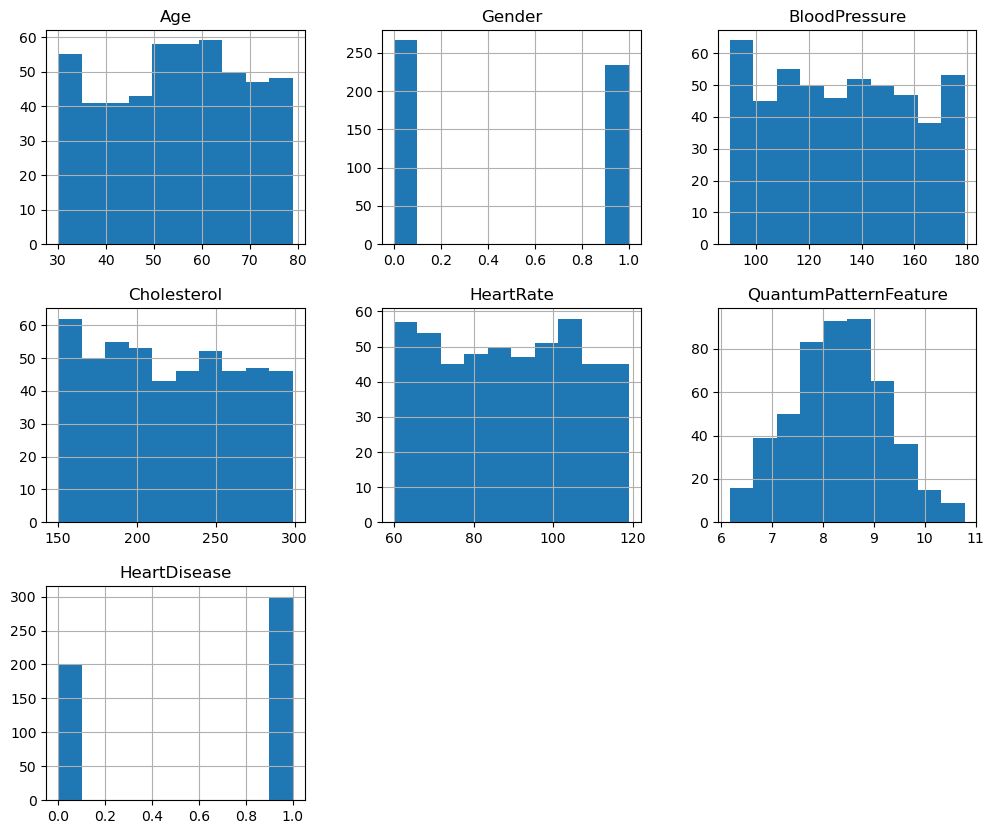

In [6]:
df.hist(figsize=(12,10))
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


**Definición del modelo de red neuronal y pipeline de preprocesamiento**

In [8]:
df = df.drop("QuantumPatternFeature", axis=1)

In [9]:
y = df["HeartDisease"]
x = df.drop("HeartDisease", axis=1)

In [10]:
num = x.drop("Gender", axis=1).columns
cat = ["Gender"]

In [24]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num),
])

In [25]:
hidden_layer_sizes = (5,10)
model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,random_state=42)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [26]:
pipeline.fit(x,y)

C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'BloodPressure', 'Cholesterol', 'HeartRate'], dtype='object'))])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [27]:
pipeline.score(x,y)

0.778

In [28]:
cross_val_score(pipeline,x,y,scoring='roc_auc_ovo',cv=10)

C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

array([0.84833333, 0.86666667, 0.76666667, 0.855     , 0.64666667,
       0.88666667, 0.87333333, 0.81833333, 0.855     , 0.87333333])

In [30]:
print("AUC promedio:", scores.mean())

AUC promedio: 0.8416666666666666


**Optimización bayesiana**

In [38]:
def f(neurons):
    n = int(neurons[0])
    hidden_layer = (n, n)
    
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        random_state=42,
        max_iter=1000
    )
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, x, y, scoring='roc_auc_ovo', cv=10)
    return np.mean(scores)

In [32]:
X_gp = np.array([[5], [10], [20]])
y_gp = np.array([f([5]), f([10]), f([20])])

C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_m

In [33]:
kernel = C(1.0) * RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel)

In [35]:
X_sim = np.linspace(5, 30, 50).reshape(-1,1)

In [36]:
for i in range(10):
    gp.fit(X_gp, y_gp)
    y_pred = gp.predict(X_sim)
    i_max = np.argmax(y_pred)
    x_new = X_sim[i_max]
    y_new = f(x_new)
    X_gp = np.vstack((X_gp, x_new))
    y_gp = np.append(y_gp, y_new)
    print(f"Iteración {i+1}: neuronas={int(x_new[0])}, AUC={y_new}")

Iteración 1: neuronas=8, AUC=0.8574999999999999


C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteración 2: neuronas=27, AUC=0.8135


C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_m

Iteración 3: neuronas=23, AUC=0.8298333333333334


C:\Users\valer\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteración 4: neuronas=7, AUC=0.8518333333333334
Iteración 5: neuronas=8, AUC=0.8574999999999999
Iteración 6: neuronas=8, AUC=0.8574999999999999
Iteración 7: neuronas=8, AUC=0.8574999999999999


C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Iteración 8: neuronas=8, AUC=0.8574999999999999
Iteración 9: neuronas=8, AUC=0.8574999999999999
Iteración 10: neuronas=8, AUC=0.8574999999999999


In [39]:
best_index = np.argmax(y_gp)
best_neurons = X_gp[best_index]
best_score = y_gp[best_index]

print("Mejor número de neuronas:", best_neurons)
print("Mejor AUC:", best_score)

Mejor número de neuronas: [8.57142857]
Mejor AUC: 0.8574999999999999


**Conclusión**

A partir del proceso de optimización bayesiana mediante Gaussian Process, se logró identificar que la mejor configuración para la red neuronal MLPClassifier corresponde aproximadamente a 8 neuronas en las capas ocultas, alcanzando un valor de AUC cercano a 0.8575. Este resultado indica que el modelo presenta una buena capacidad para distinguir entre las clases.

El proceso iterativo permitió observar cómo el modelo fue mejorando progresivamente su desempeño, pasando de configuraciones menos eficientes a una más adecuada. Esto demuestra que la relación entre el número de neuronas y el rendimiento del modelo no es lineal, y que existe un punto óptimo donde se logra un balance entre la complejidad del modelo y su capacidad de generalización.

Asimismo, el uso de optimización bayesiana permitió reducir el número de evaluaciones necesarias para encontrar una buena solución, ya que en vez de probar todas las combinaciones posibles, el modelo fue guiando la búsqueda hacia regiones más prometedoras en el espacio de hiperparámetros.